In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\lenovo\Downloads\archive\events_oct.csv',nrows=500000)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [3]:
df.info()
df['event_type'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     500000 non-null  object 
 1   event_type     500000 non-null  object 
 2   product_id     500000 non-null  int64  
 3   category_id    500000 non-null  int64  
 4   category_code  341561 non-null  object 
 5   brand          428149 non-null  object 
 6   price          500000 non-null  float64
 7   user_id        500000 non-null  int64  
 8   user_session   500000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 34.3+ MB


event_type
view        481833
purchase      9758
cart          8409
Name: count, dtype: int64

In [14]:
# Sort data
df = df.sort_values(['user_id', 'event_time'])

# Create user journeys
grouped = df.groupby('user_id')['event_type'].apply(list)

# Funnel counts
view = 0
cart = 0
purchase = 0

for events in grouped:
    if 'view' in events:
        view += 1
    if 'view' in events and 'cart' in events:
        cart += 1
    if 'view' in events and 'cart' in events and 'purchase' in events:
        purchase += 1

print("View:", view)
print("Cart:", cart)
print("Purchase:", purchase)

view_to_cart = cart / view
cart_to_purchase = purchase / cart

print("View → Cart:", view_to_cart)
print("Cart → Purchase:", cart_to_purchase)

View: 89108
Cart: 4438
Purchase: 2753
View → Cart: 0.04980473133725367
Cart → Purchase: 0.6203244704821992


In [6]:
view_to_cart = cart / view
cart_to_purchase = purchase / cart

print("View → Cart:", view_to_cart)
print("Cart → Purchase:", cart_to_purchase)

View → Cart: 0.049838398348072
Cart → Purchase: 1.6577347444269308


In [11]:
drop_view = 1 - view_to_cart
drop_cart = 1 - cart_to_purchase

print("drop view", drop_view)
print("drop cart", drop_cart)

drop view 0.950161601651928
drop cart -0.6577347444269308


In [12]:
df['event_time'] = pd.to_datetime(df['event_time'])
df['hour'] = df['event_time'].dt.hour

hourly = df.groupby('hour')['user_id'].nunique()

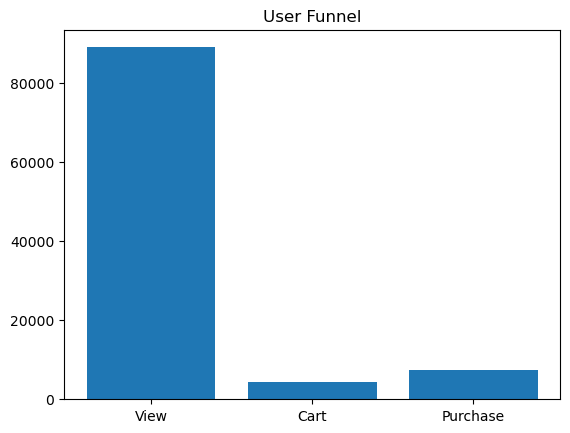

In [13]:
import matplotlib.pyplot as plt

stages = ['View', 'Cart', 'Purchase']
values = [view, cart, purchase]

plt.bar(stages, values)
plt.title("User Funnel")
plt.show()

## A/B Testing Strategy

### Problem
High drop-off observed between Cart and Purchase stage, indicating friction in the checkout process.

### Hypothesis
Reducing the number of steps in the checkout process will increase the Cart → Purchase 
conversion rate by reducing user friction.

### Experiment Design
- Control Group: Existing checkout flow
- Variant Group: Simplified checkout (fewer steps, guest checkout option)
- Traffic Split: 50% Control / 50% Variant
- Duration: 2 weeks

### Success Metrics
Primary Metric:
- Cart → Purchase conversion rate

Secondary Metrics:
- Checkout completion time
- Drop-off rate at checkout stage

### Success Criteria
- At least +5% increase in conversion rate
- No negative impact on user experience metrics

### Expected Business Impact
Improving conversion rate will directly increase revenue without increasing user acquisition costs.

## Key Insights

- Only X% of users move from viewing a product to adding it to cart, indicating low product engagement or ineffective product page design

- A drop-off of X% between cart and purchase suggests friction in the checkout process

- This represents a significant opportunity to improve conversion without increasing traffic